<table class="table table-bordered">
    <tr>
        <th style="text-align:center; width:25%"><img src='https://www.np.edu.sg/PublishingImages/Pages/default/odp/ICT.jpg' style="width: 250px; height: 125px; "></th>
        <th style="text-align:center;"><h1>Deep Learning</h1><h2>Assignment 2 - Sentiment Analysis Model (Problem 1)</h2><h3>AY2020/21 Semester</h3></th>
    </tr>
</table>

In [8]:
# Import the Required Packages
from tensorflow import keras
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import optimizers
from tensorflow.keras import regularizers
from tensorflow.keras.layers import GRU
from keras.regularizers import l2
from keras.regularizers import l1
import os
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

In [9]:
# Graph plotting function
def plot_graph(history):
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(len(acc))

    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.figure()

    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

## Step 1 – Data Loading and Processing

### 1.1 Data Loading

In [10]:
# Load the emoji_dictionary
import pandas as pd
df = pd.read_csv('mapping.csv', delimiter=',')
emoji_dictionary = df.loc[:,'emoticons'].to_dict()
print(emoji_dictionary)
print('A total of: ', len(emoji_dictionary), 'Emoji Icons')

{0: '😍', 1: '😂', 2: '📷', 3: '🔥', 4: '❤'}
A total of:  5 Emoji Icons


In [59]:
# Load the dataset
dat = pd.read_csv('data.txt', delimiter=',')
texts = dat.loc[:,'TEXT'].values
labels = dat.loc[:,'Label'].values
print(texts)
print(labels)

['Been friends since 7th grade. Look at us now we all following our dreams doing what we love and…\r\n'
 'This is what it looks like when someone loves you unconditionally oh Puppy Brother. #htx…\r\n'
 "RT @user this white family was invited to a Black barbecue and i've never laughed so hard in my life\r\n"
 ...
 'Meet Olive. Our new #GreatDane ️ ️ ️#DogsOfDenver #Dane #DogLove @ Dream Denver\r\n'
 '"I talk gray, I don\'t keep it white and black" : @user @ Three Rivers Park District -…\r\n'
 'When his baby comes to visit. ️#cheflife #chefdogs #chanceboudreaux #bloodhoundpuppy…\r\n']
[0 1 1 ... 4 2 4]


In [12]:
# Check the maximum length of texts
max_len = -1
for example in texts:
    if len(example.split()) > max_len:
        max_len = len(example.split())
        
print('the maximum length of the text inputs is ', max_len) #34 unchanged

the maximum length of the text inputs is  34


### 1.2 Data Processing


In [57]:
# Convert the texts and labels into numeric tensors
maxlen = 34
max_words = 50000 # unique words in vocab list

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
print('Found %s unique tokens.' % len(word_index))

data = pad_sequences(sequences, maxlen=maxlen, padding='post')
labels = np.asarray(labels)
print('Shape of data tensor:', data.shape)
print('Shape of label tensor:', labels.shape)

Found 56702 unique tokens.
Shape of data tensor: (42546, 34)
Shape of label tensor: (42546,)


### 1.3 Data Sampling

In [14]:
# Split the X & y into train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state = 24)
# Refer the report Appendix
# Please enter the random_state assigned to your group
print("X_train", X_train.shape)
print("y_train", y_train.shape)
print("X_test", X_test.shape)
print("y_test", y_test.shape)

X_train (34036, 34)
y_train (34036,)
X_test (8510, 34)
y_test (8510,)


## Step 2 – Develop a Sentiment Analysis Model

### Model #1 (Replicate as necessary for other models)

In [15]:
# Build the Model 16
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dropout

model = Sequential()
model.add(Embedding(max_words, 64, input_length=maxlen))
model.add(LSTM(32, return_sequences=True, dropout=(0.5)))
model.add(LSTM(32, kernel_regularizer=l2(0.0005), return_sequences=True, dropout=(0.5)))
model.add(LSTM(16))
model.add(Dropout(0.4))
model.add(Dense(5, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 34, 64)            3200000   
_________________________________________________________________
lstm (LSTM)                  (None, 34, 32)            12416     
_________________________________________________________________
lstm_1 (LSTM)                (None, 34, 32)            8320      
_________________________________________________________________
lstm_2 (LSTM)                (None, 16)                3136      
_________________________________________________________________
dropout (Dropout)            (None, 16)                0         
_________________________________________________________________
dense (Dense)                (None, 5)                 85        
Total params: 3,223,957
Trainable params: 3,223,957
Non-trainable params: 0
______________________________________________

In [16]:
# Train the Model 
model.compile(optimizer=optimizers.RMSprop(lr=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])
history = model.fit(X_train, y_train,
                    epochs=25,
                    batch_size=128,
                    validation_split=0.2)

Train on 27228 samples, validate on 6808 samples
Epoch 1/25
27228/27228 [==============================] - 36s 1ms/sample - loss: 1.2904 - acc: 0.4629 - val_loss: 1.2259 - val_acc: 0.4602
Epoch 2/25
27228/27228 [==============================] - 26s 973us/sample - loss: 1.1128 - acc: 0.5149 - val_loss: 1.1095 - val_acc: 0.5209
Epoch 3/25
27228/27228 [==============================] - 30s 1ms/sample - loss: 1.0458 - acc: 0.5549 - val_loss: 1.0804 - val_acc: 0.5463
Epoch 4/25
27228/27228 [==============================] - 29s 1ms/sample - loss: 0.9957 - acc: 0.5859 - val_loss: 1.0731 - val_acc: 0.5491
Epoch 5/25
27228/27228 [==============================] - 27s 1000us/sample - loss: 0.9533 - acc: 0.6100 - val_loss: 1.0769 - val_acc: 0.5639
Epoch 6/25
27228/27228 [==============================] - 26s 949us/sample - loss: 0.9088 - acc: 0.6359 - val_loss: 1.0926 - val_acc: 0.5737
Epoch 7/25
27228/27228 [==============================] - 29s 1ms/sample - loss: 0.8541 - acc: 0.6624 - val_lo

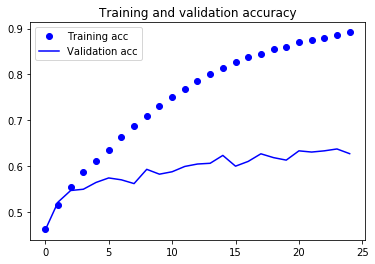

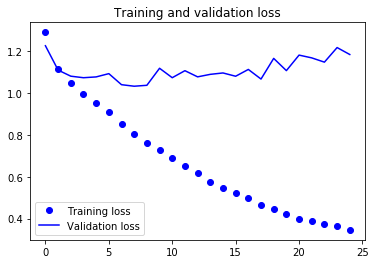

In [29]:
# Plot the Training and Validation Accuracy & Loss Scores
plot_graph(history)

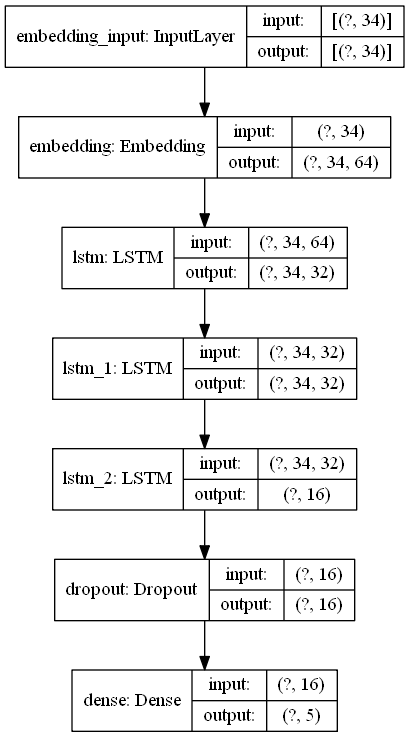

In [30]:
# Plot model
from tensorflow.keras.utils import plot_model
plot_model(model, show_shapes = True, to_file='model1.png')

In [31]:
# Save the Model
# model.save('text_model_1.h5')

### Model #2 (Replicate as necessary for other models)

In [32]:
glove_dir = 'glove.6B'

embeddings_index = {}
f = open(os.path.join(glove_dir, 'glove.6B.50d.txt'), encoding="utf8")
for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embeddings_index[word] = coefs
f.close()

print('Found %s word vectors.' % len(embeddings_index))

embedding_dim = 50

embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    embedding_vector = embeddings_index.get(word)
    if i < max_words:
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix[i] = embedding_vector

Found 400000 word vectors.


In [33]:
# Build the Model 15

model2 = Sequential()
model2.add(Embedding(max_words, embedding_dim, input_length=maxlen))
model2.add(GRU(96, return_sequences=True, dropout=(0.5)))
model2.add(GRU(48, return_sequences=True, dropout=(0.5)))
model2.add(Flatten())
model2.add(Dense(5, activation='softmax'))

model2.layers[0].set_weights([embedding_matrix])
model2.layers[0].trainable = True
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding_1 (Embedding)      (None, 34, 50)            2500000   
_________________________________________________________________
gru (GRU)                    (None, 34, 96)            42624     
_________________________________________________________________
gru_1 (GRU)                  (None, 34, 48)            21024     
_________________________________________________________________
flatten (Flatten)            (None, 1632)              0         
_________________________________________________________________
dense_1 (Dense)              (None, 5)                 8165      
Total params: 2,571,813
Trainable params: 2,571,813
Non-trainable params: 0
_________________________________________________________________


In [34]:
# Train the Model
model2.compile(optimizer=optimizers.RMSprop(lr=0.0016),
              loss='sparse_categorical_crossentropy',
              metrics=['acc'])
history2 = model2.fit(X_train, y_train,
                    epochs=25,
                    batch_size=128,
                    validation_split=0.2)

Train on 27228 samples, validate on 6808 samples
Epoch 1/25
27228/27228 [==============================] - 27s 1ms/sample - loss: 1.3006 - acc: 0.4656 - val_loss: 1.1788 - val_acc: 0.5113
Epoch 2/25
27228/27228 [==============================] - 28s 1ms/sample - loss: 1.1289 - acc: 0.5327 - val_loss: 1.0507 - val_acc: 0.5649
Epoch 3/25
27228/27228 [==============================] - 32s 1ms/sample - loss: 1.0466 - acc: 0.5638 - val_loss: 1.0235 - val_acc: 0.5905
Epoch 4/25
27228/27228 [==============================] - 35s 1ms/sample - loss: 1.0020 - acc: 0.5836 - val_loss: 0.9963 - val_acc: 0.5914
Epoch 5/25
27228/27228 [==============================] - 31s 1ms/sample - loss: 0.9719 - acc: 0.6012 - val_loss: 0.9829 - val_acc: 0.5986
Epoch 6/25
27228/27228 [==============================] - 31s 1ms/sample - loss: 0.9391 - acc: 0.6187 - val_loss: 0.9839 - val_acc: 0.6066
Epoch 7/25
27228/27228 [==============================] - 31s 1ms/sample - loss: 0.9090 - acc: 0.6294 - val_loss: 0.9

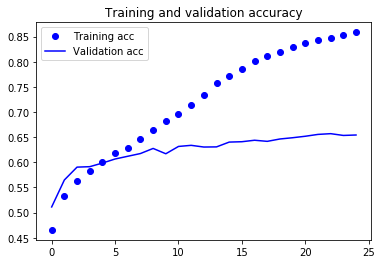

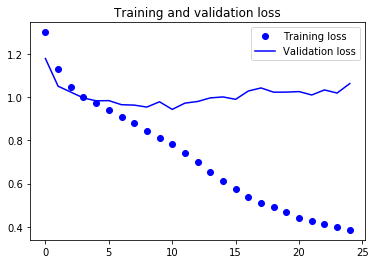

In [35]:
# Plot the Training and Validation Accuracy & Loss Scores
plot_graph(history2)

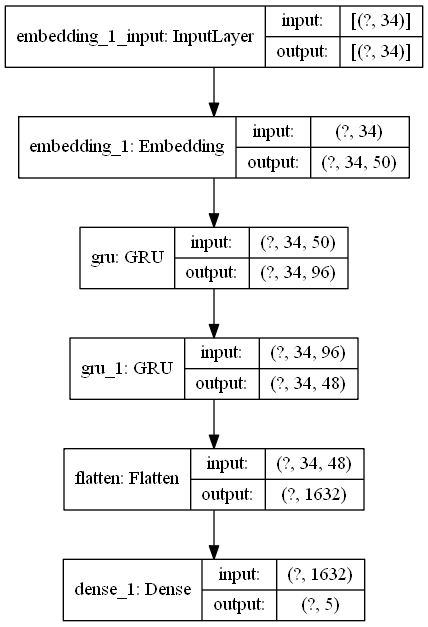

In [36]:
# Plot model
plot_model(model2, show_shapes = True, to_file='model2.png')

In [37]:
# Save the Model
# model2.save('text_model_2.h5')

## Step 3 – Evaluate the Model using Testing Data 

In [40]:
# Model #1 (replicate where necessary for other models)
# model.load_weights('text_model_1.h5')
print("Model 1:")
testResult = model.evaluate(X_test, y_test)
print(testResult)

print("\nModel 2:")
testResult2 = model2.evaluate(X_test, y_test)
print(testResult2)

Model 1:
8510/8510 [==============================] - 2s 266us/sample - loss: 1.1558 - acc: 0.6298
[1.1558194618527673, 0.6298472]

Model 2:
8510/8510 [==============================] - 2s 249us/sample - loss: 1.0333 - acc: 0.6615
[1.0332568409300018, 0.6614571]


In [ ]:
# Save the Best Model
# model.save('text_model_best.h5')

## Step 4 – Use the Best Model to make prediction

In [ ]:
# model.load_weights('text_model_best.h5')

In [ ]:
# takes the user input
# text_input = np.array([input()])

# Predict input
testList = []
userInput = input("Please enter an input: ")
testList.append(userInput)

In [ ]:
# convert the user input into numeric tensor
seq = tokenizer.texts_to_sequences(testList)
test = pad_sequences(seq, maxlen=maxlen, padding="post")

In [ ]:
# show the model output using predict function
resultTest = model.predict_classes(test)
for emoji in emoji_dictionary:
    if resultTest == emoji:
        print(emoji_dictionary.get(emoji))